# Noise in Data Labels

![label_noise_intro.png](https://live.staticflickr.com/65535/54328952408_f7e5bcb7c9_z.jpg)

*Image generated using a generative model from OpenArt.ai.*

## Introduction

Data is fundamental in machine learning. Everything starts with it. In practice, however, data is often imperfect and contains some noise that reduces its quality. One type of such noise is **label noise**, meaning that for some observations, the labels are incorrect.

The causes of label noise can vary. It often stems from subjectivity in evaluation—different experts may have differing opinions, for example when assessing emotions in images or grading essays. Another source of errors can be annotator fatigue, which affects concentration and accuracy.

Ambiguities can also arise from poor data quality, making clear classification difficult (e.g., a blurry image of a dog that resembles a wolf). Sometimes labels are generated automatically by artificial intelligence models, which can also make mistakes.

It is also worth mentioning samples that lie on the boundary between classes. Such cases, for instance in medical data where symptoms overlap across diseases, also make it difficult to assign a clear label.

Noisy data makes it harder to train a high-quality model, as the model may focus more on incorrect information than on the underlying general patterns.

## Task

Your task is to train **two** neural networks for correct binary image classification despite partial label noise in the training data. The training set is imbalanced (take this into account in your solution). The validation and test sets (which will be used to evaluate your final solution) contain only correct labels (no noise).

**The model architecture is predefined and cannot be changed.**

Think about why we use two models instead of one (this is a bit of a puzzle) — understanding this will help you grasp and solve the task.

Your role in this assignment is to implement the function `your_selected_indices(targets, losses)`, which selects indices of training samples to be used for training the models. The function takes as input a tensor of data labels (`targets`) and a tensor of loss values from both models (`losses`). The output should be a two-element list, where each element is a tensor containing indices selected for training. One model receives one set of indices, and the other model receives the second set.

Below in the notebook, you will find a cell where you should implement your function. The cell you need to modify is clearly marked. To better understand its purpose, it is worth examining the context and where this function is called within the training loop.

### Evaluation Criteria

The final evaluation will be based on the average balanced accuracy (*BAC*) of the two models:

$$
{BAC}_{mean} = \frac{BAC_1 + BAC_2}{2}
$$

where $BAC_i$ is the balanced accuracy of model $i$, $(i = 1, 2)$.

You can earn between 0 and 100 points for this task.

Your final score will be calculated using the following formula (higher is better), with rounding to integers:

$$
\mathrm{Points} =
\begin{cases}
0 & \text{if } {BAC}*{mean} \leq 0.5 \\
100 \times \frac{{BAC}*{mean} - 0.5}{0.8 - 0.5} & \text{if } 0.5 < {BAC}*{mean} < 0.8 \\
100 & \text{if } {BAC}*{mean} \geq 0.8
\end{cases}
$$

**Note:** To achieve the maximum number of points, it is not necessary to reach the maximum possible balanced accuracy of 1. If ${BAC}_{mean} \geq 0.8$, you will receive the full score.

All evaluation criteria and functions mentioned above are already implemented below.

## Constraints

* Your solution will be tested on the Competition Platform without internet access and in a GPU-enabled environment.
* Evaluation of your final solution on the platform must not exceed **5 minutes** using a GPU.
* You **cannot** modify the model architecture — it must remain the predefined `SmallMobileNet`.

## Submission Files

This notebook completed with your solution (see the `your_selected_indices` function).

## Evaluation

Remember that during evaluation, the flag `FINAL_EVALUATION_MODE` will be set to `True`.

You can earn between 0 and 100 points for this task. The number of points will be calculated on a (hidden) test set on the Competition Platform based on the previously described formula and rounded to an integer. If your solution does not meet the above criteria or fails to execute correctly, you will receive 0 points.

# Starter Code

In this section, we initialize the environment by importing the necessary libraries and functions. The provided code will help you efficiently work with the data and build the appropriate solution.

In [1]:
# W czasie sprawdzania Twojego rozwiązania, wartość flagi FINAL_EVALUATION_MODE zostanie zmieniona na True
FINAL_EVALUATION_MODE = False

In [2]:
######################### NIE ZMIENIAJ TEJ KOMÓRKI ##########################
import os
from tqdm import tqdm
from typing import Optional, Tuple, List

import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.utils.data import DataLoader

import torchvision.transforms as transforms
from torchvision.datasets.folder import VisionDataset

from sklearn.metrics import balanced_accuracy_score

## Helper Functions and Constants

In [3]:
######################### NIE ZMIENIAJ TEJ KOMÓRKI ##########################
SEED = 123
IMAGES_DIR = "data"
TASK_DATASET_LABELS_FILE = "dataset_labels.csv"

ROOT_DIR = os.getcwd()
TRAIN_DATASET_PATH = os.path.join(ROOT_DIR,'train')
VAL_DATASET_PATH = os.path.join(ROOT_DIR, 'val')

TRAIN_DATASET_URL = "1qmNNmDv-wUcAv5mvO6vYJV3mQ2SNIGnI"
VAL_DATASET_URL = "1YUJYD12NmKRSzFJGMrX-a61d6mnTaWbG"

In [4]:
######################### NIE ZMIENIAJ TEJ KOMÓRKI ##########################
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
LEARNING_RATE = 1e-2
NUM_EPOCHS = 6
NUM_CLASSES = 2
BATCH_SIZE = 128
WEIGHT_DECAY = 1e-3

if not FINAL_EVALUATION_MODE:
  print(f"Using {DEVICE} device")

Using cuda device


In [5]:
######################### NIE ZMIENIAJ TEJ KOMÓRKI ##########################
def seed_everything(seed: int) -> None:
    """
    Ustawia ziarno (seed) dla odtwarzalności wyników w Pythonie, NumPy oraz PyTorch.

    Funkcja ustawia ziarno dla generatorów liczb losowych Pythonie, NumPy oraz PyTorch,
    a także konfiguruje PyTorch do pracy w trybie deterministycznym.

    Parametry:
        seed (int): Wartość ziarna do ustawienia.
    """
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

## Data Loading

Using the code below, the data will be loaded and properly prepared.

In [6]:
######################### NIE ZMIENIAJ TEJ KOMÓRKI ##########################
def download_data(dataset_path, dataset_url):
    """Pobiera zbiór danych z Google Drive Olimpiady i zapisuje go w folderze."""
    import gdown
    import shutil

    # Utwórz lub zresetuj folder
    output = dataset_path+".zip"
    if os.path.exists(dataset_path):
        shutil.rmtree(dataset_path)
    if os.path.exists(output):
        os.remove(output)

    url = f'https://drive.google.com/uc?id={dataset_url}'
    gdown.download(url, output, fuzzy=True)

    print(f"Downloaded: {output}")

# Pobierz dane tylko jeśli nie jesteś w trybie FINAL_EVALUATION_MODE
if not FINAL_EVALUATION_MODE:
    download_data(TRAIN_DATASET_PATH, TRAIN_DATASET_URL)
    download_data(VAL_DATASET_PATH, VAL_DATASET_URL)

Downloading...
From (original): https://drive.google.com/uc?id=1qmNNmDv-wUcAv5mvO6vYJV3mQ2SNIGnI
From (redirected): https://drive.google.com/uc?id=1qmNNmDv-wUcAv5mvO6vYJV3mQ2SNIGnI&confirm=t&uuid=275cd571-5a08-469b-b8b0-9ac0f94ed4ad
To: /content/train.zip
100%|██████████| 11.9M/11.9M [00:00<00:00, 267MB/s]


Downloaded: /content/train.zip


Downloading...
From: https://drive.google.com/uc?id=1YUJYD12NmKRSzFJGMrX-a61d6mnTaWbG
To: /content/val.zip
100%|██████████| 1.19M/1.19M [00:00<00:00, 136MB/s]

Downloaded: /content/val.zip


In [7]:
######################### NIE ZMIENIAJ TEJ KOMÓRKI ##########################

# Klasa zbioru danych
class TaskDataset(VisionDataset):
    def __init__(
        self,
        root: str,
        transform: Optional[callable] = None,
    ):
        super().__init__(
            root,
            transform=transform,
        )
        self.root = root

        if not self._check_integrity():
            raise RuntimeError(
                f"Nie znaleziono zbioru danych. Sprawdź czy ścieżka {self.root} istnieje. Powinna ona zwierać folder '{IMAGES_DIR}' i plik '{TASK_DATASET_LABELS_FILE}' file"
            )
        self.labels_df = self._read_labels_from_file()
        self.labels_header = 'label'

    def _read_labels_from_file(self) -> pd.DataFrame:
        df = pd.read_csv(os.path.join(self.root, TASK_DATASET_LABELS_FILE))
        return df

    def _check_integrity(self) -> bool:
        return os.path.exists(os.path.join(self.root, IMAGES_DIR)) and os.path.exists(
            os.path.join(self.root, TASK_DATASET_LABELS_FILE)
        )

    def __len__(self) -> int:
        return len(self.labels_df)

    def __getitem__(self, idx: int) -> Tuple[Image.Image, np.ndarray]:
        img = self._load_image(idx)
        label = self._load_label(idx)
        if self.transform is not None:
            img = self.transform(img)
        return img, label

    def _load_image(self, idx: int) -> Image.Image:
        img_path = os.path.join(
            self.root, IMAGES_DIR, self.labels_df.iloc[idx]['file_name']
        )
        img = Image.open(img_path)
        return img

    def _load_label(self, idx: int):
        label = self.labels_df.iloc[idx][self.labels_header]
        return np.array([int(label)])

In [8]:
######################### NIE ZMIENIAJ TEJ KOMÓRKI ##########################
def unpack_data(unpack_path, dataset_name) -> None:
    dataset_zip_path = os.path.join(ROOT_DIR, dataset_name+".zip")
    dataset_local_dir = os.path.join(unpack_path, dataset_name)
    if not os.path.exists(dataset_local_dir):
        if not os.path.exists(dataset_zip_path):
            raise FileNotFoundError(
                f"Nie znaleziono pliku {dataset_zip_path} w bieżącym folderze."
            )

        with zipfile.ZipFile(dataset_zip_path, "r") as zip_ref:
            zip_ref.extractall(unpack_path)

In [9]:
######################### NIE ZMIENIAJ TEJ KOMÓRKI ##########################
# Funkcja ładująca dane treningowe i walidacyjne
def load_data() -> Tuple[DataLoader, DataLoader]:
    """
    Funkcja ładująca dane treningowe i walidacyjne przy użyciu klasy TaskDataset.

    Funkcja tworzy zbiory danych dla danych treningowych oraz walidacyjnych,
    stosuje podstawową transformację (konwersję do tensora), a następnie
    opakowuje je w obiekty DataLoader.

    Zwraca:
        Tuple[DataLoader, DataLoader]: Obiekty DataLoader dla zbioru treningowego oraz walidacyjnego.
    """
    base_transform = transforms.Compose([transforms.ToTensor()])

    train_dataset = TaskDataset(root=TRAIN_DATASET_PATH, transform=base_transform)
    val_dataset = TaskDataset(root=VAL_DATASET_PATH, transform=base_transform)

    train_loader = DataLoader(
        dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=False
    )
    val_loader = DataLoader(dataset=val_dataset, batch_size=BATCH_SIZE, shuffle=False)

    return train_loader, val_loader

In [10]:
######################### NIE ZMIENIAJ TEJ KOMÓRKI ##########################
# Rozpakujmy i załadujmy dane
if not FINAL_EVALUATION_MODE:
    unpack_data(ROOT_DIR, "train")
    unpack_data(ROOT_DIR, "val")
    train_loader, val_loader = load_data()

## Model Architecture

In [11]:
######################### NIE ZMIENIAJ TEJ KOMÓRKI ##########################
class SmallMobileNet(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super(SmallMobileNet, self).__init__()

        # Główne bloki konwolucyjne
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU6(inplace=True),
            nn.Conv2d(
                32, 32, kernel_size=3, stride=1, padding=1, groups=32, bias=False
            ),
            nn.BatchNorm2d(32),
            nn.ReLU6(inplace=True),
            nn.Conv2d(32, 64, kernel_size=1, stride=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU6(inplace=True),
            nn.Conv2d(
                64, 64, kernel_size=3, stride=2, padding=1, groups=64, bias=False
            ),
            nn.BatchNorm2d(64),
            nn.ReLU6(inplace=True),
            nn.Conv2d(64, 128, kernel_size=1, stride=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU6(inplace=True),
            nn.Conv2d(
                128, 128, kernel_size=3, stride=2, padding=1, groups=128, bias=False
            ),
            nn.BatchNorm2d(128),
            nn.ReLU6(inplace=True),
            nn.Conv2d(128, 256, kernel_size=1, stride=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU6(inplace=True),
        )

        self.pool = nn.AdaptiveAvgPool2d(1)

        self.classifier = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU6(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

## Evaluation Metric Code

Code similar to the one below will be used to evaluate the solution on the test set.

In [12]:
######################### NIE ZMIENIAJ TEJ KOMÓRKI ##########################
def predict_and_evaluate(model, val_loader, device, verbose=False):
    model.eval()
    all_preds, all_targets = [], []

    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())

    balanced_accuracy = balanced_accuracy_score(all_targets, all_preds)

    if verbose:
        print(f"Balanced Accuracy: {balanced_accuracy}")

    return balanced_accuracy

In [13]:
######################### NIE ZMIENIAJ TEJ KOMÓRKI ##########################
def performance(bac_1: float, bac_2: float) -> None:
    """
    Oblicza i wypisuje wynik wydajności na podstawie dwóch wartości balanced accuracy.

    Ostateczny wynik to średnia z obu wartości, przeskalowana między ustalonymi granicami,
    co przekłada się na liczbę zdobytych punktów.

    Parametry:
        bac_1 (float): Wartość balanced accuracy dla pierwszego modelu.
        bac_2 (float): Wartość balanced accuracy dla drugiego modelu.
    """
    bac_mean = (bac_1 + bac_2) / 2
    if bac_mean <= 0.5:
        points = 0
    elif 0.5 < bac_mean < 0.8:
        points = (bac_mean - 0.5) / (0.8 - 0.5) * 100
        points = int(round(points))
    else:
        points = 100

    print(
        f"Twoje rozwiązanie ma średnią wartość balanced accuracy równą {round(bac_mean, 5)} na zbiorze walidacyjnym, co daje {points}/100 punktów."
    )
    return points

## Training Model

In [14]:
######################### NIE ZMIENIAJ TEJ KOMÓRKI ##########################


# Funkcja do trenowania modelu
def train(
    model1,
    model2,
    optimizer1,
    optimizer2,
    criterion,
    train_loader,
    val_loader,
    num_epochs,
    device,
    select_indices_fn,
):

    verbose = False if FINAL_EVALUATION_MODE else True

    # Historia metryk dla każdego modelu
    metrics = {
        k: [[], []]
        for k in [
            "train_loss",
            "val_loss",
            "train_bac",
            "val_bac",
        ]
    }
    epochs_range = np.arange(num_epochs) + 1

    # Główna pętla treningowa
    for epoch in epochs_range:
        print(f"Epoch {epoch}")

        # Historia statystyk dla każdego modelu
        stats = {
            k: [0, 0] for k in ["train_loss", "train_total", "val_loss", "val_total"]
        }
        preds_targets = {
            k: [[], []]
            for k in ["train_preds", "train_targets", "val_preds", "val_targets"]
        }

        model1.train(), model2.train()
        for inputs, targets in tqdm(train_loader, desc=f"Epoch {epoch}/{num_epochs}"):
            inputs, targets = inputs.to(device), targets.squeeze().long().to(device)

            outputs = [m(inputs) for m in (model1, model2)]
            losses = [criterion(out, targets) for out in outputs]

            # --- GŁÓWNY PUNKT ZADANIA ---
            selected_indices = select_indices_fn(targets, losses)
            # ---------------------------

            # Propagacja wsteczna dla każdego modelu
            for i, (model, optim) in enumerate(
                [(model1, optimizer1), (model2, optimizer2)]
            ):
                optim.zero_grad()
                sel_idx = selected_indices[i]
                loss = criterion(model(inputs[sel_idx]), targets[sel_idx]).mean()

                loss.backward()
                optim.step()

                # Historia statystyk
                stats["train_loss"][i] += loss.item() * len(sel_idx)
                stats["train_total"][i] += len(sel_idx)
                preds = outputs[i].max(1)[1]
                preds_targets["train_preds"][i].extend(preds[sel_idx].cpu().numpy())
                preds_targets["train_targets"][i].extend(targets[sel_idx].cpu().numpy())

        # Ewaluacja na zbiorze walidacyjnym
        if verbose:
            model1.eval(), model2.eval()
            with torch.no_grad():
                for inputs, targets in tqdm(
                    val_loader, desc=f"Validation {epoch}/{num_epochs}"
                ):
                    inputs, targets = inputs.to(device), targets.squeeze().long().to(
                        device
                    )

                    for i, model in enumerate([model1, model2]):
                        outputs = model(inputs)
                        loss = criterion(outputs, targets).mean()
                        preds = outputs.max(1)[1]

                        stats["val_loss"][i] += loss.item() * inputs.size(0)
                        stats["val_total"][i] += inputs.size(0)
                        preds = outputs.max(1)[1]
                        preds_targets["val_preds"][i].extend(preds.cpu().numpy())
                        preds_targets["val_targets"][i].extend(targets.cpu().numpy())

        # Obliczanie metryk
        if verbose:
            models = [model1, model2]
            for i in range(2):
                for phase in ["train", "val"]:
                    preds = preds_targets[f"{phase}_preds"][i]
                    targets = preds_targets[f"{phase}_targets"][i]

                    metrics[f"{phase}_loss"][i].append(
                        stats[f"{phase}_loss"][i] / stats[f"{phase}_total"][i]
                    )
                    metrics[f"{phase}_bac"][i].append(
                        balanced_accuracy_score(targets, preds)
                    )

                print(
                    f"Model{i+1} - Train Loss: {metrics['train_loss'][i][-1]:.4f}, "
                    f"Train balanced accuracy: {metrics['train_bac'][i][-1]:.4f} --- "
                    f"Validation Loss: {metrics['val_loss'][i][-1]:.4f}, "
                    f"Validation balanced accuracy: {metrics['val_bac'][i][-1]:.4f}, "
                )

    # Generowanie wykresów
    if verbose:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
        colors = ["#fa2729", "#ac1a1c", "#1a6aff", "#144aad"]
        linestyles = ["-", "--"]

        for i, model_name in enumerate(["Model1", "Model2"]):
            for j, phase in enumerate(["train", "val"]):

                color = colors[i * 2 + j]
                ax1.plot(
                    epochs_range,
                    metrics[f"{phase}_loss"][i],
                    color=color,
                    marker="o",
                    linestyle=linestyles[j],
                    label=f"{model_name} {phase.title()} Loss",
                )
                ax2.plot(
                    epochs_range,
                    metrics[f"{phase}_bac"][i],
                    color=color,
                    marker="o",
                    linestyle=linestyles[j],
                    label=f"{model_name} {phase.title()} balanced accuracy",
                )

        for ax, title in zip([ax1, ax2], ["Loss", "Balanced accuracy"]):
            ax.set_title(f"Training and Validation {title}")
            ax.set_xticks(epochs_range)
            ax.set_xlabel("Epochs")
            ax.set_ylabel(title)
            ax.legend()

        plt.tight_layout()
        plt.show()

## Example Solution
Below we present a simplified solution that serves as an example demonstrating the basic functionality of the notebook. It can be used as a starting point for developing your own solution.

In [15]:
######################### NIE ZMIENIAJ TEJ KOMÓRKI ##########################
def default_select_indices(targets, losses):
    # Wszystkie indeksy dla obu modeli
    selected_indices = [torch.arange(targets.shape[0]).to(DEVICE) for _ in range(2)]
    return selected_indices

Epoch 1


Validation 1/6: 100%|██████████| 8/8 [00:00<00:00, 14.68it/s]


Model1 - Train Loss: 0.6398, Train balanced accuracy: 0.5020 --- Validation Loss: 0.7998, Validation balanced accuracy: 0.5000, 
Model2 - Train Loss: 0.6396, Train balanced accuracy: 0.5031 --- Validation Loss: 0.6857, Validation balanced accuracy: 0.5000, 
Epoch 2


Validation 2/6: 100%|██████████| 8/8 [00:00<00:00, 15.23it/s]


Model1 - Train Loss: 0.5988, Train balanced accuracy: 0.5007 --- Validation Loss: 1.2756, Validation balanced accuracy: 0.5000, 
Model2 - Train Loss: 0.5921, Train balanced accuracy: 0.5120 --- Validation Loss: 0.6825, Validation balanced accuracy: 0.5000, 
Epoch 3


...

Model1 - Train Loss: 0.5753, Train balanced accuracy: 0.5000 --- Validation Loss: 0.6695, Validation balanced accuracy: 0.5000, 
Model2 - Train Loss: 0.5718, Train balanced accuracy: 0.5152 --- Validation Loss: 0.7908, Validation balanced accuracy: 0.5000, 
Epoch 5


Validation 5/6: 100%|██████████| 8/8 [00:00<00:00, 15.33it/s]


Model1 - Train Loss: 0.5679, Train balanced accuracy: 0.5000 --- Validation Loss: 1.6361, Validation balanced accuracy: 0.5000, 
Model2 - Train Loss: 0.5651, Train balanced accuracy: 0.5255 --- Validation Loss: 0.6252, Validation balanced accuracy: 0.5000, 
Epoch 6


Validation 6/6: 100%|██████████| 8/8 [00:00<00:00, 14.54it/s]


Model1 - Train Loss: 0.5679, Train balanced accuracy: 0.5000 --- Validation Loss: 1.4500, Validation balanced accuracy: 0.5000, 
Model2 - Train Loss: 0.5682, Train balanced accuracy: 0.5000 --- Validation Loss: 1.7490, Validation balanced accuracy: 0.5000, 


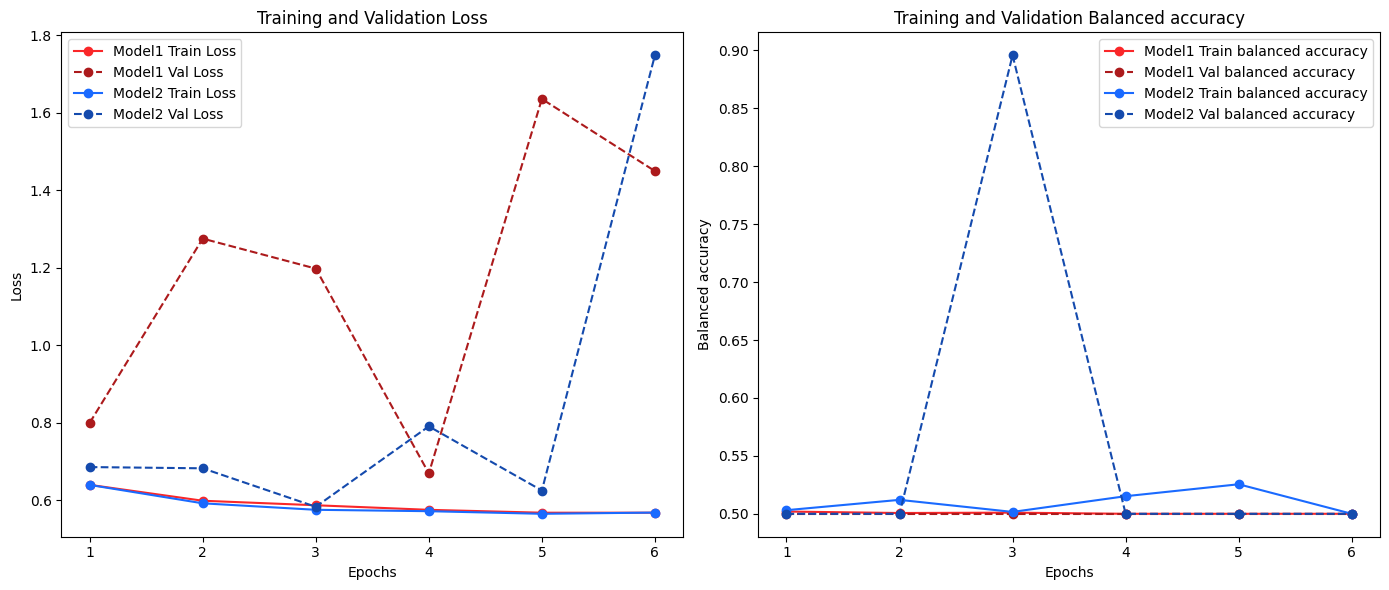

Balanced Accuracy: 0.5
Balanced Accuracy: 0.5
Twoje rozwiązanie ma średnią wartość balanced accuracy równą 0.5 na zbiorze walidacyjnym, co daje 0/100 punktów.


In [16]:
######################### NIE ZMIENIAJ TEJ KOMÓRKI ##########################
# WAŻNE: Trenujemy zawsze dwa modele i ewaluujemy

if not FINAL_EVALUATION_MODE:
    seed_everything(SEED)
    criterion = nn.CrossEntropyLoss(reduction="none")

    model1 = SmallMobileNet(NUM_CLASSES).to(DEVICE)
    model2 = SmallMobileNet(NUM_CLASSES).to(DEVICE)

    optimizer1 = AdamW(model1.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    optimizer2 = AdamW(model2.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

    seed_everything(SEED)
    train(
        model1,
        model2,
        optimizer1,
        optimizer2,
        criterion,
        train_loader,
        val_loader,
        NUM_EPOCHS,
        DEVICE,
        select_indices_fn=default_select_indices,
    )

    # Ewaluacja przykładowego rozwiązania
    bac_1 = predict_and_evaluate(model1, val_loader, DEVICE, verbose=True)
    bac_2 = predict_and_evaluate(model2, val_loader, DEVICE, verbose=True)

    performance(bac_1, bac_2)

# Model Solution

### Table of Contents

1. [Introduction to the model solution](#wdmr)
2. [Data Exploration](#data-exploration)
3. [Experimental data balancing](#experimental-data-balancing)
4. [Solution](#solution)

The text below is a comprehensive description of an example benchmark approach to the task. If you are only interested in the implementation of the `your_selected_indices` function, you can jump directly to the [Solution](#solution) section. However, we encourage you to read the full text to better understand the context and approach to the problem.

### <h3 id="wdmr"> Introduction to the Model Solution </h3>

##### Evaluation Metric: Balanced Accuracy

The Balanced Accuracy metric is primarily used when dealing with imbalanced datasets, where individual classes are not equally represented. In such cases, standard Accuracy can produce misleadingly high results, especially if one class dominates and the model simply ignores the less frequent ones. This is particularly important in domains such as medicine or fraud detection, where “positive” cases (e.g., disease, fraud) are naturally much rarer than negative ones.

Balanced Accuracy is defined as the arithmetic mean of recall (sensitivity) computed for each class:

$$
\text{Balanced Accuracy} = \frac{1}{K} \sum_{i=1}^K \frac{TP_i}{TP_i + FN_i}
$$

where:

* $K$ – number of classes,
* $TP_i$, $FN_i$ – respectively the number of true positives and false negatives for class (i), as predicted by the model.

In the simplest case of binary classification (two classes), this formula reduces to the average of Sensitivity and Specificity:

$$
\text{Balanced Accuracy} = \frac{1}{2} \left( \frac{TP}{TP + FN} + \frac{TN}{TN + FP} \right)
$$


##### What can cause low Balanced Accuracy?

A low Balanced Accuracy score can have several main causes. Beyond the issue of imbalanced data—where the dominance of one class makes it harder for the model to learn minority classes—a very common culprit is poor data quality. This includes issues such as incorrect labels, high noise levels, or annotation mistakes made during labeling.

Another problem is an improperly chosen model. It may be either too simple to capture meaningful patterns (underfitting), or conversely too complex and effectively “memorizing” the training data (overfitting). Performance can also be affected by an unsuitable architecture, poorly tuned hyperparameters, or insufficient training time.

##### So how can we address low performance?

The key step is balancing the training data, for example through *oversampling* (duplicating minority class samples) or *undersampling* (removing majority class samples). Data augmentation is also often helpful, as it artificially increases data diversity. If that is not enough, optimization of the model itself becomes necessary. This can involve experimenting with architecture changes, hyperparameter tuning, or applying regularization techniques.

A particularly popular and effective approach is modifying the loss function so that it assigns higher weight to errors made on minority classes. This forces the model to pay more attention to them.

Finally, it is always worth improving data quality—analyzing the dataset for incorrect labels and removing noise where possible. If that is not feasible, transfer learning techniques can help by leveraging knowledge from models pretrained on larger, related datasets.

To precisely diagnose where the problem lies, we start by analyzing the confusion matrix of the initial models trained using the baseline solution (we use all indices for training both models).

It shows how the model performs for each class and between which classes it most frequently makes mistakes.

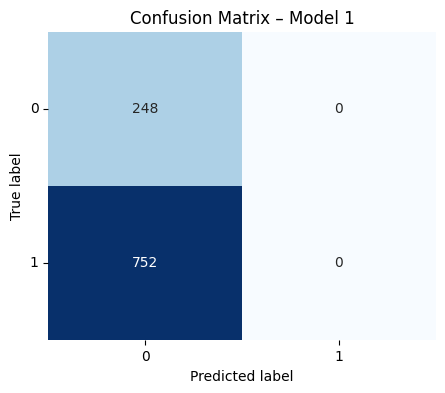

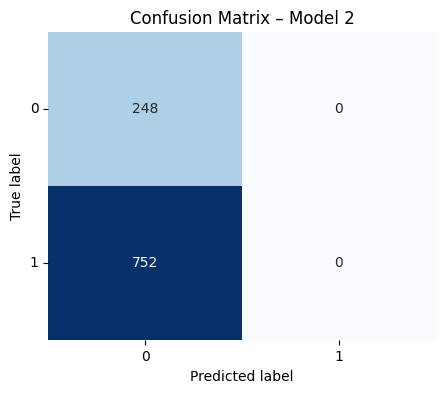

In [17]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(cm, model_name):
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f"Confusion Matrix – {model_name}")
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.xticks([0.5, 1.5], ["0", "1"])
    plt.yticks([0.5, 1.5], ["0", "1"], rotation=0)
    plt.show()

# Zbierz predykcje i prawdziwe etykiety dla obu modeli
for idx, model in enumerate([model1, model2], start=1):
    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(DEVICE), targets.squeeze().long().to(DEVICE)
            outputs = model(inputs)
            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
    cm = confusion_matrix(all_targets, all_preds)
    plot_confusion_matrix(cm, f"Model {idx}")

The conclusions are clear: models 1 and 2 always predict class 0, which results in a very low Balanced Accuracy score, since this metric rewards balanced performance across both classes. It is also worth noting that in the validation set, approximately 75% of the labels belong to class 1, which is underrepresented in the training data.

### Data Exploration

Before moving on to model building, we first need to carefully examine the data to understand its structure and assess its quality. This exploratory data analysis (EDA) will include several key steps:

* **Checking class distribution:** We will start by analyzing the training set to see how frequently each class appears, in order to determine whether the dataset is balanced.
* **Data quality assessment:** We will look for any issues such as missing values, obvious errors, or potentially incorrect labels that could interfere with the learning process.
* **Feature visualization:** We will prepare appropriate plots (e.g., histograms for continuous variables, box plots) to visually inspect the distribution of feature values.

For numerical data, we will compute key statistical measures (mean, median, standard deviation), which will help us better understand the overall characteristics of the dataset.

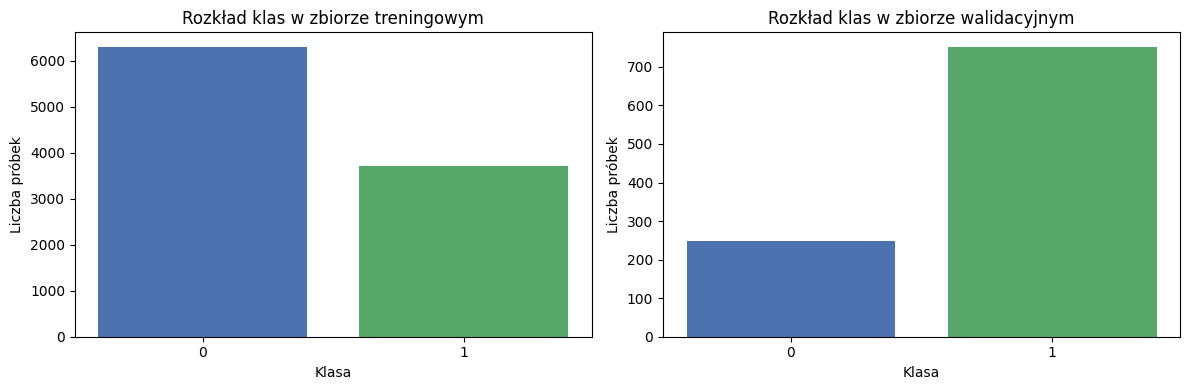

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# dystrybucja zbioru treningowego
train_targets = torch.cat([t.squeeze() for _, t in train_loader]).cpu().numpy()
axes[0].bar([0, 1], [(train_targets == 0).sum(), (train_targets == 1).sum()],
            color=['#4c72b0', '#55a868'])
axes[0].set_xticks([0, 1])
axes[0].set_title("Rozkład klas w zbiorze treningowym")
axes[0].set_xlabel("Klasa")
axes[0].set_ylabel("Liczba próbek")

# dystrybucja zbioru walidacyjnego
val_targets = torch.cat([t.squeeze() for _, t in val_loader]).cpu().numpy()
axes[1].bar([0, 1], [(val_targets == 0).sum(), (val_targets == 1).sum()],
            color=['#4c72b0', '#55a868'])
axes[1].set_xticks([0, 1])
axes[1].set_title("Rozkład klas w zbiorze walidacyjnym")
axes[1].set_xlabel("Klasa")
axes[1].set_ylabel("Liczba próbek")

plt.tight_layout()
plt.show()

**Observation:** It is immediately clear that we are dealing with imbalanced data, and in a rather unusual way. In the training set, class 0 clearly dominates, while in the validation set the proportions are reversed — class 1 appears much more frequently there.

Such a discrepancy can significantly hinder training. The model, learning from the training data, will naturally start favoring the more frequent class 0. However, when evaluated on the validation set, it will turn out to be poorly adapted, since class 1 dominates there instead.

We should also remember that the task concerns “label noise.” This, combined with our observations, increasingly suggests that we cannot fully trust the data — especially given how different the distributions are between the training and validation sets. At the same time, we are guaranteed that the validation labels are correct. All of this clearly indicates that we need to approach model design and training much more carefully than simply feeding all samples into the model.

Braki w etykietach w kolumnie 'file_name': 0
Braki w etykietach  w kolumnie 'label': 0

Liczba próbek wg klasy: label
0    6298
1    3702
Name: count, dtype: int64

Brakujące pliki obrazów: 0


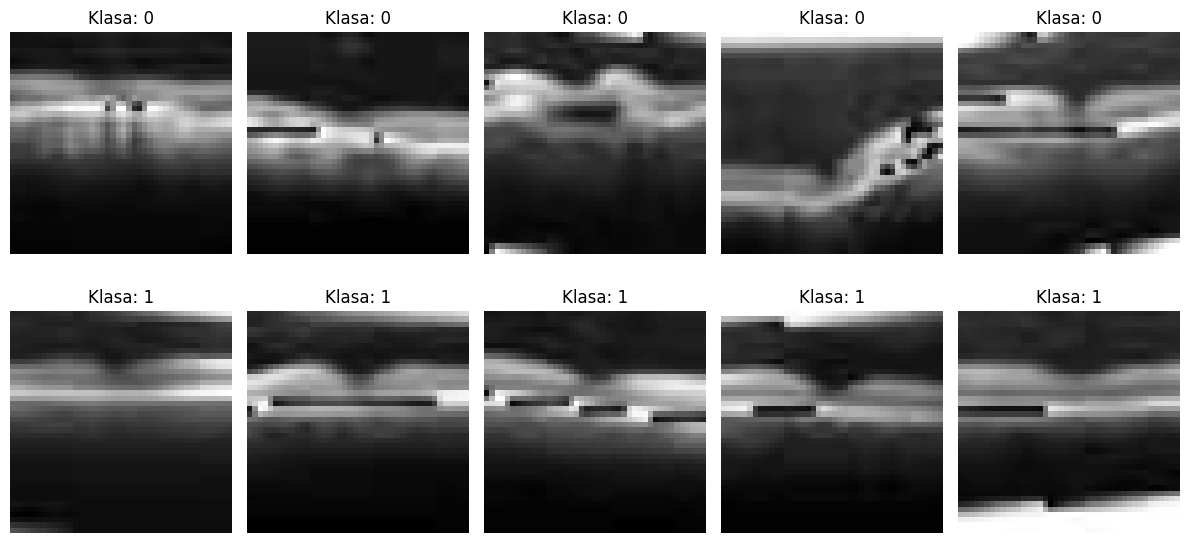

In [19]:
# Sprawdzenie braków i rozkładu etykiet
labels_df = train_loader.dataset.labels_df
print("Braki w etykietach w kolumnie 'file_name':", labels_df['file_name'].isnull().sum())
print("Braki w etykietach  w kolumnie 'label':", labels_df['label'].isnull().sum())
print("\nLiczba próbek wg klasy:", labels_df['label'].value_counts())

# Sprawdzenie, czy pliki obrazów istnieją
missing = [
    fn for fn in labels_df['file_name']
    if not os.path.exists(os.path.join(TRAIN_DATASET_PATH, IMAGES_DIR, fn))
]
print(f"\nBrakujące pliki obrazów: {len(missing)}")

# Wyświetlenie losowych próbek z każdej klasy
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
for cls in [0, 1]:
    cls_samples = labels_df[labels_df['label'] == cls].sample(5, random_state=SEED)
    for i, (_, row) in enumerate(cls_samples.iterrows()):
        img = Image.open(os.path.join(TRAIN_DATASET_PATH, IMAGES_DIR, row['file_name']))
        ax = axes[cls, i]
        ax.imshow(img, cmap='gray')
        ax.set_title(f"Klasa: {cls}")
        ax.axis('off')
plt.tight_layout()
plt.show()

In this case, it is difficult to determine whether the data is mislabeled, since we do not have domain knowledge. However, in some situations, visualizations can be used to observe how the data is distributed in feature space.

Let us therefore use techniques such as PCA or t-SNE to reduce the dimensionality of the data and visualize how different classes are separated in the feature space.

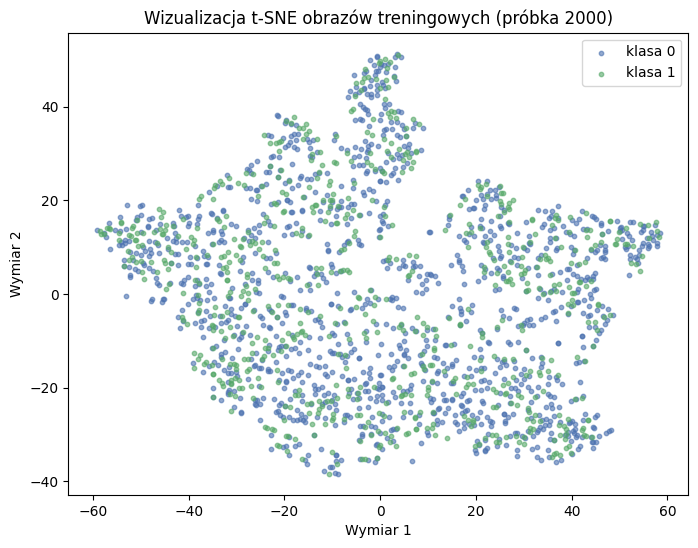

In [20]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import numpy as np

import matplotlib.pyplot as plt

# Krok 1: Ekstrakcja obrazów i etykiet.
imgs, lbls = [], []
for inputs, targets in train_loader:
    # Spłaszczenie obrazów i konwersja na NumPy array.
    b = inputs.view(inputs.size(0), -1).cpu().numpy()
    imgs.append(b)
    # Konwersja etykiet na NumPy array.
    lbls.append(targets.squeeze().cpu().numpy())

imgs = np.vstack(imgs)
lbls = np.concatenate(lbls)

# Inicjalizacja generatora liczb losowych.
rng = np.random.default_rng(SEED)

# Wybór losowej próbki 2000 obrazów.
sel = rng.choice(len(imgs), size=2000, replace=False)
X_sub, y_sub = imgs[sel], lbls[sel]

# Krok 2: Redukcja wymiarowości (PCA, a następnie t-SNE).
# PCA do wstępnej redukcji do 50 komponentów.
pca = PCA(n_components=50, random_state=SEED)
X_pca = pca.fit_transform(X_sub)

# t-SNE do redukcji do 2 wymiarów dla wizualizacji.
tsne = TSNE(n_components=2, random_state=SEED, init='pca', learning_rate='auto')
X_2d = tsne.fit_transform(X_pca)

# Krok 3: Wizualizacja danych 2D.
plt.figure(figsize=(8,6))
for cls, c in zip([0,1], ['#4c72b0','#55a868']):
    mask = y_sub == cls
    plt.scatter(X_2d[mask,0], X_2d[mask,1], s=10, c=c, label=f"klasa {cls}", alpha=0.6)
plt.legend()
plt.title("Wizualizacja t-SNE obrazów treningowych (próbka 2000)")
plt.xlabel("Wymiar 1")
plt.ylabel("Wymiar 2")
plt.show()


In this case, there is no clear separation between the classes, which may suggest that the data is inherently difficult to classify. Based on the visualization, we cannot conclude that the data is mislabeled, as there are no obvious outliers or inconsistencies.

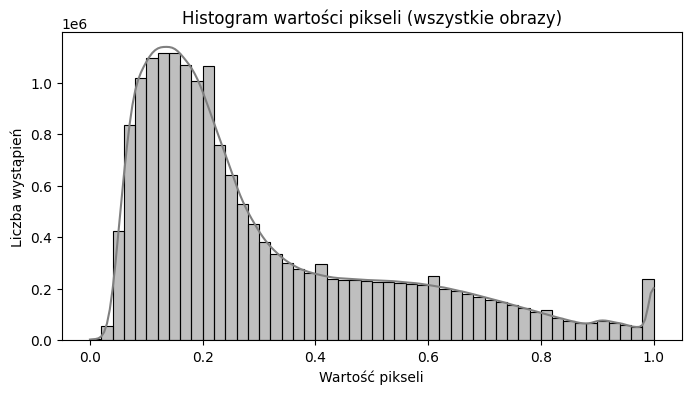

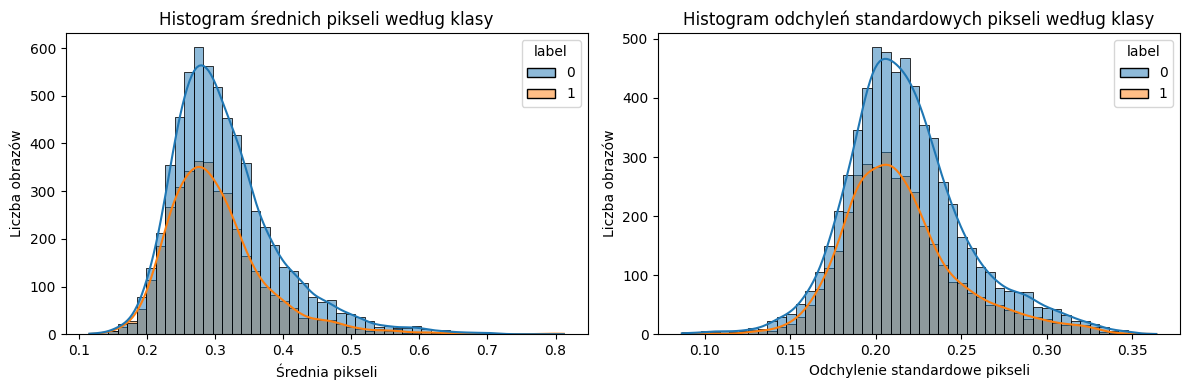

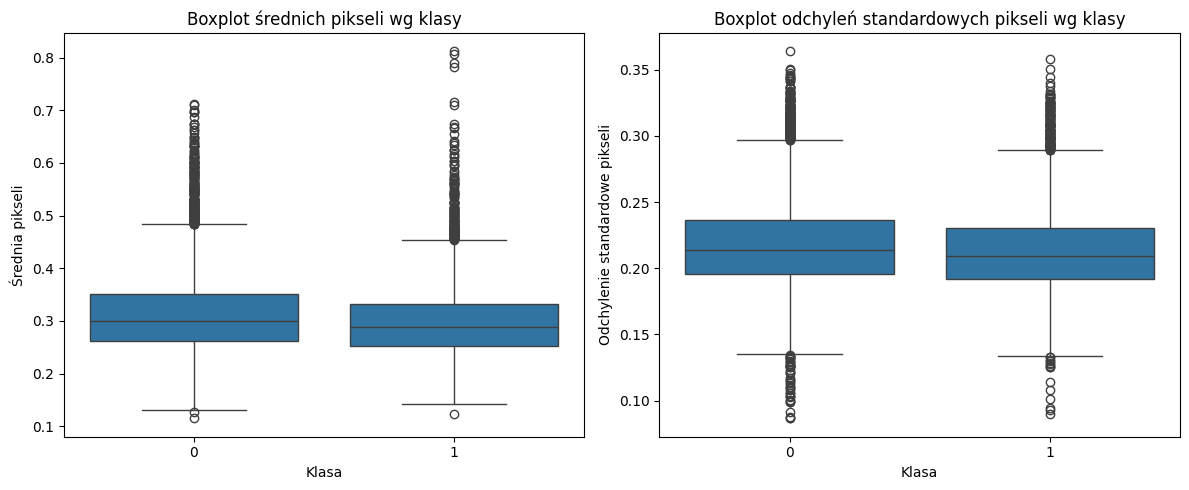

In [21]:
# Przygotowanie danych: spłaszczone obrazy i metryki per-obraz
pixel_values = imgs.flatten()
means = imgs.mean(axis=1)
stds = imgs.std(axis=1)
eda_df = pd.DataFrame({'mean': means, 'std': stds, 'label': lbls})

# Histogram rozkładu wartości pikseli w całym zbiorze
plt.figure(figsize=(8,4))
sns.histplot(pixel_values, bins=50, color='gray', kde=True)
plt.title("Histogram wartości pikseli (wszystkie obrazy)")
plt.xlabel("Wartość pikseli")
plt.ylabel("Liczba wystąpień")
plt.show()

# Histogramy średnich i odchyleń standardowych per klasa
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.histplot(eda_df, x='mean', hue='label', bins=50, kde=True)
plt.title("Histogram średnich pikseli według klasy")
plt.xlabel("Średnia pikseli")
plt.ylabel("Liczba obrazów")

plt.subplot(1,2,2)
sns.histplot(eda_df, x='std', hue='label', bins=50, kde=True)
plt.title("Histogram odchyleń standardowych pikseli według klasy")
plt.xlabel("Odchylenie standardowe pikseli")
plt.ylabel("Liczba obrazów")
plt.tight_layout()
plt.show()

# Boxploty średnich i odchyleń per klasa
fig, axes = plt.subplots(1,2, figsize=(12,5))
sns.boxplot(x='label', y='mean', data=eda_df, ax=axes[0])
axes[0].set_title("Boxplot średnich pikseli wg klasy")
axes[0].set_xlabel("Klasa")
axes[0].set_ylabel("Średnia pikseli")

sns.boxplot(x='label', y='std', data=eda_df, ax=axes[1])
axes[1].set_title("Boxplot odchyleń standardowych pikseli wg klasy")
axes[1].set_xlabel("Klasa")
axes[1].set_ylabel("Odchylenie standardowe pikseli")

plt.tight_layout()
plt.show()

The plots above also show that the pixel values for images from both classes are similar, which may suggest that the data is difficult to classify.

### Initial idea for the solution – “Co-Teaching”

In this method, two models learn in parallel (which is exactly what is required in this task). Each of them selects samples that it considers most reliable (i.e., those with the **lowest loss**). Then the models **exchange** these samples: one model trains on data selected by the other, and vice versa. This helps avoid learning from incorrect, noisy labels.

This way of training models, although intuitive, was formally introduced in the paper *“Co-teaching: Robust Training of Deep Neural Networks with Extremely Noisy Labels”* ([https://arxiv.org/abs/1804.06872](https://arxiv.org/abs/1804.06872)).

### Experimental step leading to the reference solution: Variation of the Co-Teaching approach

The goal of this experiment is to understand how different sampling strategies (i.e., what percentage of examples from each class we select) affect the final class distribution in the training set. We test this in the context of a method inspired by **Co-Teaching**.

What exactly does this code do? It should be noted that **this is not a full implementation of Co-Teaching training**, but rather a variation of it. It is an analytical tool used to examine how different sampling strategies (percentage-based class selection) influence the distribution of selected samples. This is a preparatory step intended to help fine-tune the data selection strategy before running the actual training process.

The script works as follows:

1. It takes a single batch of data (images and their labels).
2. It computes losses for both models, estimating how difficult each sample is.
3. It simulates different predefined class sampling strategies (e.g., selecting 30% of class 0 samples and 80% of class 1 samples).
4. It selects the **easiest samples** using losses from one model to choose examples for the other.
5. Finally, it counts and visualizes the results — showing how many samples from each class were selected and how the distribution looks for each tested strategy.

This experiment is meant to help choose the **best class sampling proportions**. We are looking for a strategy that simultaneously:

* **filters the data** (via loss-based selection),
* **properly balances classes** (by choosing appropriate percentages),
* and ultimately **improves model performance**, which can be measured for example by higher BAC (Balanced Accuracy).

The goal was to find such sampling coefficients for classes 0 and 1 so that the resulting training batch is balanced (i.e., close to a 50%/50% class distribution). This is a key strategy for optimizing Balanced Accuracy, which rewards models that perform well across both classes.


In [22]:
def test_sampling_rates(targets, losses, number_of_batches):
    # Pobierz dane do wizualizacji
    sample_targets = targets
    sample_losses1, sample_losses2 = losses

    # Policz próbki w każdej klasie
    class_counts = [np.sum(sample_targets == i) for i in range(NUM_CLASSES)]
    print(f"Rozkład klas w {number_of_batches} batchach: Klasa 0: {class_counts[0]}, Klasa 1: {class_counts[1]}")

    # Zdefiniuj strategie próbkowania do testów
    sampling_rates_to_test = [
        [0.3, 0.3],  # Równe niskie próbkowanie
        [0.8, 0.8],  # Równe wysokie próbkowanie
        [0.5, 0.5],  # Równe zbalansowane próbkowanie
        [0.3, 0.8],  # Więcej z klasy 1
        [0.8, 0.3],  # Więcej z klasy 0
        [0.5, 0.85],  # Wybrana strategia 1
        [0.5, 0.92]   # Wybrana strategia 2
    ]

    results = {}

    for rates in sampling_rates_to_test:
        selected_class0 = []
        selected_class1 = []

        for class_idx in range(NUM_CLASSES):
            class_mask = sample_targets == class_idx
            class_indices = np.where(class_mask)[0]
            take_n = int(len(class_indices) * rates[class_idx])

            # Użyj strat z przeciwnego modelu
            temp_losses = sample_losses2.copy()
            temp_losses[~class_mask] = float('inf')
            selected_indices = np.argsort(temp_losses)[:take_n]

            if class_idx == 0:
                selected_class0.extend(selected_indices)
            else:
                selected_class1.extend(selected_indices)

        total_selected = len(selected_class0) + len(selected_class1)
        results[f"Rates {rates}"] = {
            "class0_count": len(selected_class0),
            "class1_count": len(selected_class1),
            "total": total_selected,
            "class0_percent": len(selected_class0) / max(1, total_selected) * 100,
            "class1_percent": len(selected_class1) / max(1, total_selected) * 100
        }

    # Wyświetl wyniki
    for rate_name, stats in results.items():
        print(f"{rate_name}:")
        print(f"  Klasa 0: {stats['class0_count']} próbek ({stats['class0_percent']:.1f}%)")
        print(f"  Klasa 1: {stats['class1_count']} próbek ({stats['class1_percent']:.1f}%)")
        print(f"  Razem: {stats['total']} próbek")
        print()

    # Wizualizuj strategie próbkowania
    plt.figure(figsize=(12, 6))
    bar_width = 0.35
    rate_names = list(results.keys())
    x = np.arange(len(rate_names))

    plt.bar(x - bar_width/2, [results[r]["class0_percent"] for r in rate_names],
            bar_width, label='Klasa 0')
    plt.bar(x + bar_width/2, [results[r]["class1_percent"] for r in rate_names],
            bar_width, label='Klasa 1')

    plt.xlabel('Strategia próbkowania')
    plt.ylabel('Procent wybranych próbek')
    plt.title('Rozkład klas dla różnych strategii próbkowania')
    plt.xticks(x, [r.replace("Rates ", "") for r in rate_names], rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

Rozkład klas w 10 batchach: Klasa 0: 830, Klasa 1: 450
Rates [0.3, 0.3]:
  Klasa 0: 249 próbek (64.8%)
  Klasa 1: 135 próbek (35.2%)
  Razem: 384 próbek

Rates [0.8, 0.8]:
  Klasa 0: 664 próbek (64.8%)
  Klasa 1: 360 próbek (35.2%)
  Razem: 1024 próbek

Rates [0.5, 0.5]:
  Klasa 0: 415 próbek (64.8%)
  Klasa 1: 225 próbek (35.2%)
  Razem: 640 próbek

Rates [0.3, 0.8]:
  Klasa 0: 249 próbek (40.9%)
  Klasa 1: 360 próbek (59.1%)
  Razem: 609 próbek

Rates [0.8, 0.3]:
  Klasa 0: 664 próbek (83.1%)
  Klasa 1: 135 próbek (16.9%)
  Razem: 799 próbek

Rates [0.5, 0.85]:
  Klasa 0: 415 próbek (52.1%)
  Klasa 1: 382 próbek (47.9%)
  Razem: 797 próbek

Rates [0.5, 0.92]:
  Klasa 0: 415 próbek (50.1%)
  Klasa 1: 414 próbek (49.9%)
  Razem: 829 próbek



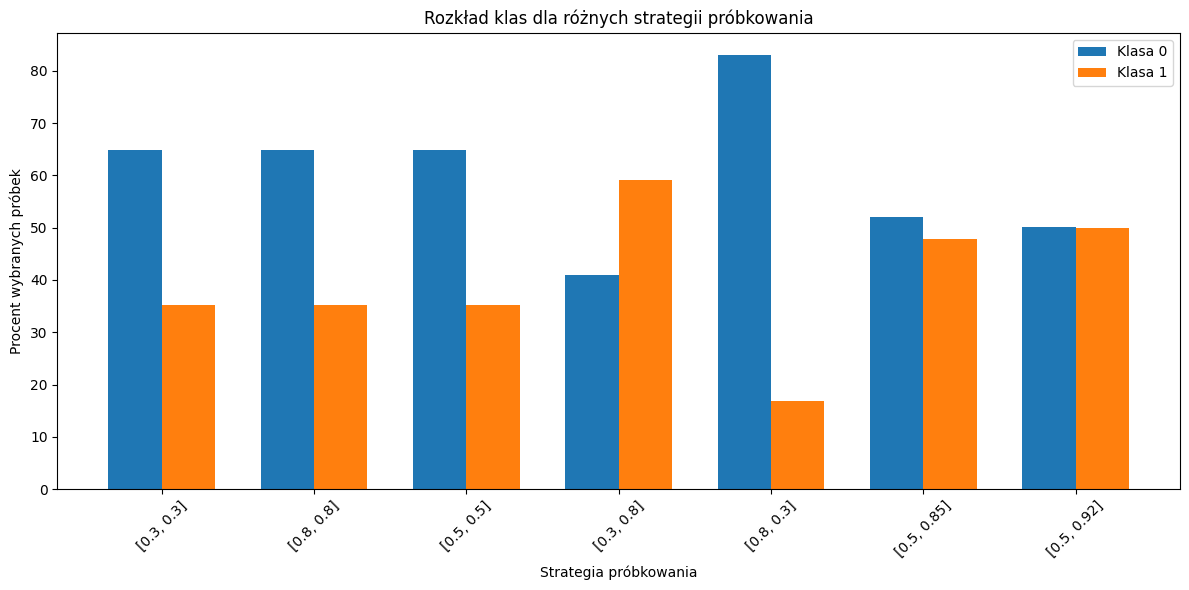

In [23]:
# Eksperymenty nie muszą wchodzić w skład ostatecznego rozwiązania
if not FINAL_EVALUATION_MODE:
    # Tworzymy akumulator, aby zebrać wyniki z 10 batchów
    number_of_batches = 10
    targets_acc, losses1_acc, losses2_acc = np.array([]), np.array([]), np.array([])
    for _ in range(min(number_of_batches, len(train_loader))):
        inputs, targets = next(iter(train_loader))
        inputs, targets = inputs.to(DEVICE), targets.squeeze().long().to(DEVICE)

        # Pobierz straty z obu modeli
        model1.eval()
        model2.eval()
        with torch.no_grad():
            outputs1 = model1(inputs)
            outputs2 = model2(inputs)

            loss1 = criterion(outputs1, targets)
            loss2 = criterion(outputs2, targets)

        targets_acc = np.concatenate((targets_acc, targets.cpu().numpy()), axis=0)
        losses1_acc = np.concatenate((losses1_acc, loss1.cpu().numpy()), axis=0)
        losses2_acc = np.concatenate((losses2_acc, loss2.cpu().numpy()), axis=0)

    test_sampling_rates(targets_acc, [losses1_acc, losses2_acc], number_of_batches)

For the strategy [0.5, 0.92], we almost perfectly balance the classes, since we obtain 50% of samples from class 0 and 50% of samples from class 1.

<h3 id="solution"> Solution </h3>

This function selects the most reliable examples from a data batch that will be used to train two models.

#### How does it work?

1. **We have two models**, each of which evaluates every sample by assigning a loss value (the lower it is, the better the model understands the sample).
2. **Each model selects data for the other model** — this helps reduce the impact of incorrect labels.
3. **A fraction of samples from each class (0 and 1) is selected** (based on our experiment):

   * 50% of examples from class 0
   * 92% of examples from class 1
4. **The selected samples are the ones considered easiest by the other model** (i.e., those with the lowest loss).

The approach used is therefore a hybrid of two strategies: (1) Selecting samples with low loss (inspired by Co-Teaching) helps filter out potentially noisy samples (with incorrect labels). (2) Differential sampling rates ([0.5, 0.92]) simultaneously correct the class imbalance in the original training set. As a result, the model learns from “clean” and “balanced” data.

In [24]:
def your_select_indices(
    targets: torch.Tensor, losses: List[torch.Tensor]
) -> List[torch.Tensor]:
    """
    Funkcja wybierająca indeksy zbioru treningowego do wykorzystania podczas trenowania modeli.

    Parametry:
        targets: Etykiety danych treningowych z danego batcha jako tensor. Wymiar: (batch_size,)
        losses: Dwuelementowa lista zawierająca tensory wartości funkcji straty dla poszczególnych modeli. Wymiar: [(batch_size,), (batch_size,)]

    Zwraca:
        Listę indeksów wybranych do aktualizacji wag modeli.
    """
    # Współczynniki próbkowania wybrany na podstawie eksperymentu
    take_n_by_class = [0.5, 0.93]
    # Inicjalizacja listy do przechowywania wybranych indeksów
    selected_indices = [[] for _ in range(2)]

    # Przetwarzanie klas osobno
    for class_idx in torch.unique(targets):
        # Wybór próbek dla bieżącej klasy
        class_mask = targets == class_idx
        class_indices = class_mask.nonzero(as_tuple=True)[0]
        take_n = int(len(class_indices) * take_n_by_class[class_idx])

        # Dla każdego modelu
        for i in range(2):
            # Selekcja krzyżowa - użyj strat z przeciwnego modelu
            t = losses[1 - i].clone().to(DEVICE)

            # Wybierz próbki o najniższej stracie tylko z bieżącej klasy
            t[targets.to(DEVICE) != class_idx] = float("Inf")
            _, best_idx = torch.topk(-t, k=take_n)

            # Dodaj wybrane indeksy do zbioru treningowego modelu
            selected_indices[i].extend(best_idx.cpu().tolist())

    return selected_indices

# Evaluation

Running the cells below will allow you to check how many points your solution would achieve on the validation data. Before submission, make sure that the entire notebook (including with the `FINAL_EVALUATION_MODE = True` flag set) executes from start to finish without errors and without requiring any user intervention after selecting “Run All”.


In [25]:
######################### NIE ZMIENIAJ TEJ KOMÓRKI ##########################
def final_evaluate(evaluate_data_path, model1, model2):

    base_transform = transforms.Compose([transforms.ToTensor()])
    evaluate_dataset = TaskDataset(root=evaluate_data_path, transform=base_transform)
    evaluate_loader = DataLoader(
        dataset=evaluate_dataset, batch_size=BATCH_SIZE, shuffle=False
    )

    bac_1 = predict_and_evaluate(model1, evaluate_loader, DEVICE, verbose=True)
    bac_2 = predict_and_evaluate(model2, evaluate_loader, DEVICE, verbose=True)
    return performance(bac_1, bac_2)

Epoch 1


Validation 1/6: 100%|██████████| 8/8 [00:00<00:00, 12.28it/s]


Model1 - Train Loss: 0.3713, Train balanced accuracy: 0.8164 --- Validation Loss: 0.5418, Validation balanced accuracy: 0.8130, 
Model2 - Train Loss: 0.3674, Train balanced accuracy: 0.8239 --- Validation Loss: 0.8104, Validation balanced accuracy: 0.7882, 
Epoch 2


Validation 2/6: 100%|██████████| 8/8 [00:00<00:00, 15.09it/s]


Model1 - Train Loss: 0.2596, Train balanced accuracy: 0.8758 --- Validation Loss: 0.4013, Validation balanced accuracy: 0.8047, 
Model2 - Train Loss: 0.2618, Train balanced accuracy: 0.8719 --- Validation Loss: 0.6793, Validation balanced accuracy: 0.8347, 
Epoch 3


...

Model1 - Train Loss: 0.2139, Train balanced accuracy: 0.8913 --- Validation Loss: 0.9433, Validation balanced accuracy: 0.7984, 
Model2 - Train Loss: 0.2199, Train balanced accuracy: 0.8904 --- Validation Loss: 0.9091, Validation balanced accuracy: 0.7637, 
Epoch 5


Validation 5/6: 100%|██████████| 8/8 [00:00<00:00, 11.96it/s]


Model1 - Train Loss: 0.2258, Train balanced accuracy: 0.8858 --- Validation Loss: 0.7836, Validation balanced accuracy: 0.8184, 
Model2 - Train Loss: 0.2238, Train balanced accuracy: 0.8838 --- Validation Loss: 0.3019, Validation balanced accuracy: 0.8534, 
Epoch 6


Validation 6/6: 100%|██████████| 8/8 [00:00<00:00, 14.63it/s]


Model1 - Train Loss: 0.2006, Train balanced accuracy: 0.8958 --- Validation Loss: 0.3175, Validation balanced accuracy: 0.8687, 
Model2 - Train Loss: 0.2020, Train balanced accuracy: 0.8965 --- Validation Loss: 0.3505, Validation balanced accuracy: 0.8938, 


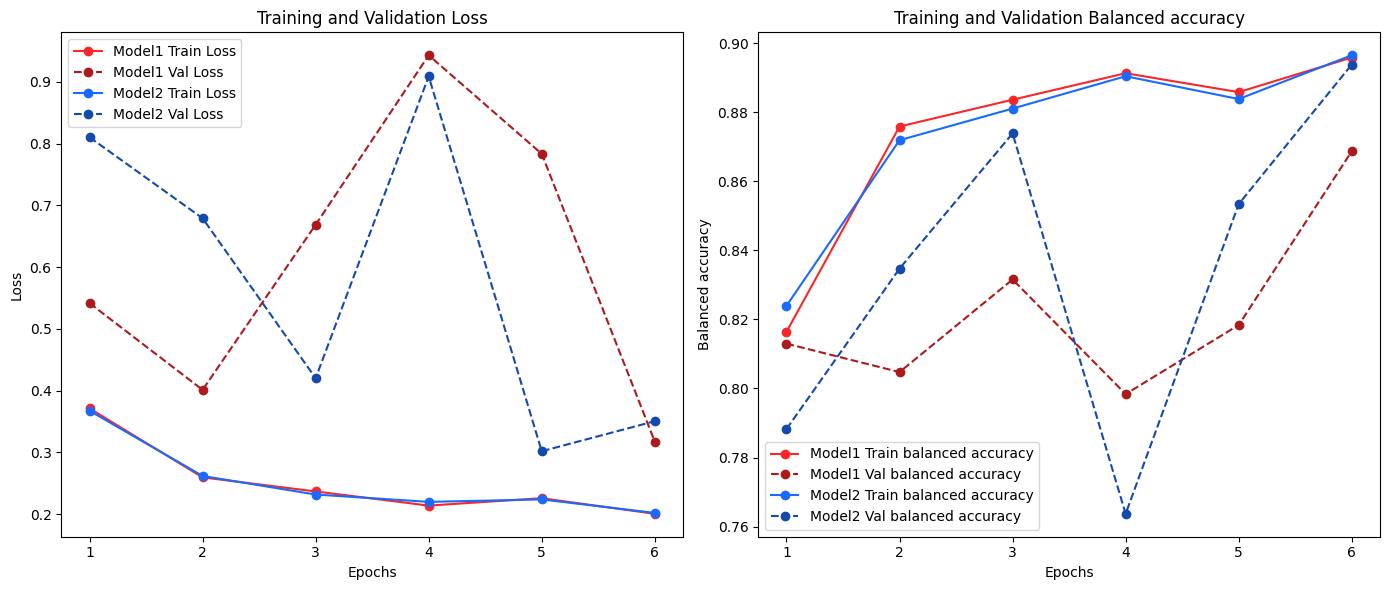

Balanced Accuracy: 0.8686727865477007
Balanced Accuracy: 0.8937886067261496
Twoje rozwiązanie ma średnią wartość balanced accuracy równą 0.88123 na zbiorze walidacyjnym, co daje 100/100 punktów.


In [26]:
######################### NIE ZMIENIAJ TEJ KOMÓRKI ##########################
if not FINAL_EVALUATION_MODE:
    seed_everything(SEED)
    criterion = nn.CrossEntropyLoss(reduction="none")

    model1 = SmallMobileNet(NUM_CLASSES).to(DEVICE)
    model2 = SmallMobileNet(NUM_CLASSES).to(DEVICE)

    optimizer1 = AdamW(model1.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    optimizer2 = AdamW(model2.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

    seed_everything(SEED)
    train(
        model1,
        model2,
        optimizer1,
        optimizer2,
        criterion,
        train_loader,
        val_loader,
        NUM_EPOCHS,
        DEVICE,
        select_indices_fn=your_select_indices,
    )

    final_evaluate(VAL_DATASET_PATH, model1, model2)

Your function `your_select_indices` will be saved to a file named `your_select_indices.pkl`, and then used to train the models on the training set (according to the code above). The final number of points will be computed based on classification performance on the test set.

In [27]:
######################### NIE ZMIENIAJ TEJ KOMÓRKI ##########################
if FINAL_EVALUATION_MODE:
    import cloudpickle

    OUTPUT_PATH = "file_output"
    FUNCTION_FILENAME = "your_select_indices.pkl"
    FUNCTION_OUTPUT_PATH = os.path.join(OUTPUT_PATH, FUNCTION_FILENAME)

    if not os.path.exists(OUTPUT_PATH):
        os.makedirs(OUTPUT_PATH)

    with open(FUNCTION_OUTPUT_PATH, "wb") as f:
        cloudpickle.dump(your_select_indices, f)